In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils import data
import torch
import torchvision.transforms as transforms
import torch.nn as nn
from tqdm import tqdm
from matplotlib import pyplot as plt
from torchsummary import summary

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Default Implementation

In [ ]:
transform = transforms.Compose([
        transforms.Resize((124,124)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))        
    ])
dataset = ImageFolder('drive/MyDrive/data/New/',transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = data.random_split(dataset, [train_size, test_size])
train_dataloader = data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
test_dataloader = data.DataLoader(test_dataset, batch_size=4, shuffle=True, num_workers=4)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [ ]:
num_classes = 5
learning_rate = 1e-3
num_epochs = 50

In [ ]:
class Classification_NN(nn.Module):
    def __init__(self,num_classes):
        super(Classification_NN, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels= 3, out_channels=2, kernel_size=(3,3), stride=1, padding=0),
                                   nn.Sigmoid())
        self.Pool1 = nn.MaxPool2d(kernel_size=(2,2))
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels= 2, out_channels=2, kernel_size=(3,3), stride=1, padding=0),
                                   nn.ReLU())
        self.Pool2 = nn.MaxPool2d(kernel_size=(2,2))
        self.FC1 = nn.Sequential(nn.Linear(1682,50),
                                 nn.ReLU())
        self.Output = nn.Sequential(nn.Linear(50,5),
                                    nn.Softmax())
    def forward(self, x):
        out = self.conv1(x)
        out = self.Pool1(out)

        out = self.conv2(out)
        out = self.Pool2(out)

        out = out.reshape(out.size(0), -1)

        out = self.FC1(out)
        out = self.Output(out)

        return out
        


In [ ]:
model = Classification_NN(num_classes=num_classes).to(device)
summary(model,(3,124,124))
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)  


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 2, 122, 122]              56
           Sigmoid-2          [-1, 2, 122, 122]               0
         MaxPool2d-3            [-1, 2, 61, 61]               0
            Conv2d-4            [-1, 2, 59, 59]              38
              ReLU-5            [-1, 2, 59, 59]               0
         MaxPool2d-6            [-1, 2, 29, 29]               0
            Linear-7                   [-1, 50]          84,150
              ReLU-8                   [-1, 50]               0
            Linear-9                    [-1, 5]             255
          Softmax-10                    [-1, 5]               0
Total params: 84,499
Trainable params: 84,499
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.18
Forward/backward pass size (MB): 0.63
Params size (MB): 0.32
Estimated Tot

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


In [ ]:
train_accuracy = []
train_loss = []
test_accuracy = []
test_loss = []

for epoch in range(num_epochs):
    correct = 0
    total = 0
    for (images, labels) in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy.append(correct / total)
    train_loss.append(loss.item())


    with torch.no_grad():  
        correct = 0
        total = 0
        for (images, labels) in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy.append(correct / total)
        test_loss.append(loss.item())

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_accuracy[-1]*100:.2f}%, Test Loss: {test_loss[-1]:.4f}, Test Acc: {test_accuracy[-1]*100:.2f}%')
    

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Epoch [1/50], Train Loss: 1.6100, Train Acc: 22.31%, Test Loss: 1.6071, Test Acc: 32.82%
Epoch [2/50], Train Loss: 1.6073, Train Acc: 25.19%, Test Loss: 1.5995, Test Acc: 32.82%
Epoch [3/50], Train Loss: 1.6054, Train Acc: 25.19%, Test Loss: 1.6037, Test Acc: 32.82%
Epoch [4/50], Train Loss: 1.6119, Train Acc: 25.19%, Test Loss: 1.5761, Test Acc: 32.82%
Epoch [5/50], Train Loss: 1.6068, Train Acc: 25.19%, Test Loss: 1.5986, Test Acc: 32.82%
Epoch [6/50], Train Loss: 1.6331, Train Acc: 25.19%, Test Loss: 1.5770, Test Acc: 32.82%


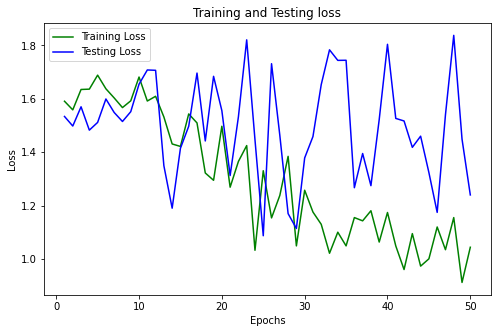

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss)+1), train_loss, 'g', label='Training Loss')
plt.plot(range(1, len(test_loss)+1), test_loss, 'b', label='Testing Loss')

plt.title('Training and Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

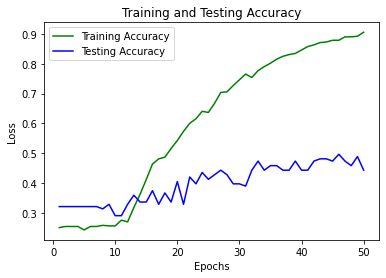

In [ ]:
plt.figure()
plt.plot(range(1, len(train_accuracy)+1), train_accuracy, 'g', label='Training Accuracy')
plt.plot(range(1, len(test_accuracy)+1), test_accuracy, 'b', label='Testing Accuracy')

plt.title('Training and Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Improved Implementation

In [ ]:
transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.2),                                   # Randomly flip horizontally as a data augmentation
        transforms.Resize((124,124)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))        # Normalizing using the mean and std of ImageNet
    ])
dataset = ImageFolder('drive/MyDrive/New/',transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = data.random_split(dataset, [train_size, test_size])
train_dataloader = data.DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=4)
test_dataloader = data.DataLoader(test_dataset, batch_size=4, shuffle=True, num_workers=4)

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))


In [ ]:
num_classes = 5
learning_rate = 1e-3
num_epochs = 50

In [ ]:
class Classification_NN_modified(nn.Module):
    def __init__(self,num_classes):
        super(Classification_NN_modified, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels= 3, out_channels=4, kernel_size=(3,3), stride=1, padding=0), 
                                   nn.Sigmoid())                # increased the number of feature maps to 4
        self.Pool1 = nn.MaxPool2d(kernel_size=(2,2))
        self.conv2 = nn.Sequential(nn.Conv2d(in_channels= 4, out_channels=8, kernel_size=(3,3), stride=1, padding=0),
                                   nn.ReLU())                   # increased the number of feature maps to 8
        self.Pool2 = nn.MaxPool2d(kernel_size=(2,2))
        self.conv3 = nn.Sequential(nn.Conv2d(in_channels= 8, out_channels=8, kernel_size=(3,3), stride=1, padding=0),
                                   nn.ReLU())                   # adding an additional conv layer with 8 feature maps and ReLU activation 
        self.Pool3 = nn.MaxPool2d(kernel_size=(2,2))            
        self.FC1 = nn.Sequential(nn.Linear(1352,100),
                                 nn.ReLU())                     # increased the number of neurons to 100
        self.Output = nn.Sequential(nn.Linear(100,5),
                                    nn.Softmax())
    def forward(self, x):
        out = self.conv1(x)
        out = self.Pool1(out)

        out = self.conv2(out)
        out = self.Pool2(out)

        out = self.conv3(out)
        out = self.Pool3(out)

        out = out.reshape(out.size(0), -1)

        out = self.FC1(out)
        out = self.Output(out)

        return out
        


In [ ]:
model_updated = Classification_NN_modified(num_classes=num_classes).to(device)
summary(model_updated,(3,124,124))
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_updated.parameters(), lr=learning_rate) 


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 4, 122, 122]             112
           Sigmoid-2          [-1, 4, 122, 122]               0
         MaxPool2d-3            [-1, 4, 61, 61]               0
            Conv2d-4            [-1, 8, 59, 59]             296
              ReLU-5            [-1, 8, 59, 59]               0
         MaxPool2d-6            [-1, 8, 29, 29]               0
            Conv2d-7            [-1, 8, 27, 27]             584
              ReLU-8            [-1, 8, 27, 27]               0
         MaxPool2d-9            [-1, 8, 13, 13]               0
           Linear-10                  [-1, 100]         135,300
             ReLU-11                  [-1, 100]               0
           Linear-12                    [-1, 5]             505
          Softmax-13                    [-1, 5]               0
Total params: 136,797
Trainable params:

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


In [ ]:
train_accuracy = []
train_loss = []
test_accuracy = []
test_loss = []

for epoch in range(num_epochs):
    correct = 0
    total = 0
    for (images, labels) in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model_updated(images)
        
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_accuracy.append(correct / total)
    train_loss.append(loss.item())


    with torch.no_grad():  
        correct = 0
        total = 0
        for (images, labels) in test_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_updated(images)

            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        test_accuracy.append(correct / total)
        test_loss.append(loss.item())

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss[-1]:.4f}, Train Acc: {train_accuracy[-1]*100:.2f}%, Test Loss: {test_loss[-1]:.4f}, Test Acc: {test_accuracy[-1]*100:.2f}%')
    

/usr/local/lib/python3.7/dist-packages/torch/utils/data/dataloader.py:481: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  cpuset_checked))
/usr/local/lib/python3.7/dist-packages/torch/nn/modules/container.py:141: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  input = module(input)


Epoch [1/50], Train Loss: 1.5685, Train Acc: 24.81%, Test Loss: 1.6237, Test Acc: 28.24%
Epoch [2/50], Train Loss: 1.5521, Train Acc: 27.88%, Test Loss: 1.3325, Test Acc: 28.24%
Epoch [3/50], Train Loss: 1.6893, Train Acc: 25.96%, Test Loss: 1.4426, Test Acc: 28.24%
Epoch [4/50], Train Loss: 1.6471, Train Acc: 30.00%, Test Loss: 1.4894, Test Acc: 32.06%
Epoch [5/50], Train Loss: 1.4232, Train Acc: 36.54%, Test Loss: 1.1643, Test Acc: 34.35%
Epoch [6/50], Train Loss: 1.6583, Train Acc: 38.46%, Test Loss: 1.0989, Test Acc: 41.98%
Epoch [7/50], Train Loss: 1.5619, Train Acc: 45.77%, Test Loss: 1.5441, Test Acc: 32.82%
Epoch [8/50], Train Loss: 1.1351, Train Acc: 45.58%, Test Loss: 1.6729, Test Acc: 42.75%
Epoch [9/50], Train Loss: 1.2844, Train Acc: 45.96%, Test Loss: 1.6305, Test Acc: 45.80%
Epoch [10/50], Train Loss: 1.2382, Train Acc: 48.46%, Test Loss: 1.3471, Test Acc: 48.09%
Epoch [11/50], Train Loss: 1.1255, Train Acc: 50.19%, Test Loss: 1.2153, Test Acc: 46.56%
Epoch [12/50], Trai

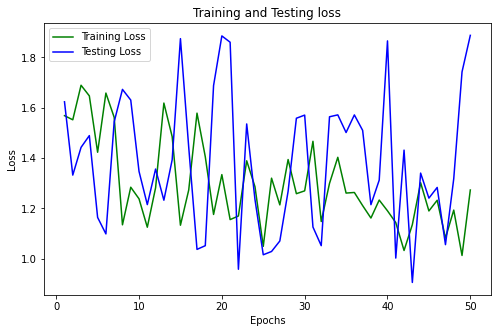

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss)+1), train_loss, 'g', label='Training Loss')
plt.plot(range(1, len(test_loss)+1), test_loss, 'b', label='Testing Loss')

plt.title('Training and Testing loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

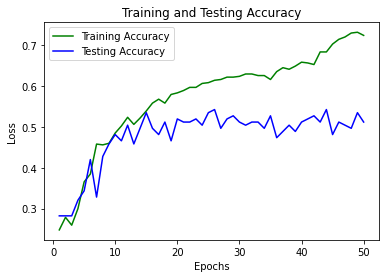

In [ ]:
plt.figure()
plt.plot(range(1, len(train_accuracy)+1), train_accuracy, 'g', label='Training Accuracy')
plt.plot(range(1, len(test_accuracy)+1), test_accuracy, 'b', label='Testing Accuracy')

plt.title('Training and Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()